# MTGFlow su PVGIS

Workflow guidato per preparare i CSV climatici, eseguire MTGFlow e analizzare gli score. Gli script restano la fonte riproducibile; il notebook li orchestra senza duplicare la logica.

Protocollo: **training 2005–2018**, **target/test 2019**, z-score e soglie calcolati esclusivamente sul training.

In [1]:
from pathlib import Path
import os
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / 'pyproject.toml').is_file():
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Avviare il notebook dalla root del repository o da notebooks/.')

# Modificare soltanto questo percorso.
PVGIS_DIR = Path(os.environ.get(
    'PVGIS_DIR', '/data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance'
))
OUTPUT_ROOT = ROOT / 'outputs' / 'pvgis_mtgflow'
PREPARED_DIR = OUTPUT_ROOT / 'prepared'
MANIFEST = PREPARED_DIR / 'manifest_shard_0000.csv'
DEVICE = 'cuda'

RUN_PREPARATION = not MANIFEST.is_file()
RUN_SMOKE = False
RUN_FULL = False
RUN_DOWNSTREAM = True
print('Repository:', ROOT)
print('PVGIS:', PVGIS_DIR)

Repository: /home/apedalino/physiq_pv
PVGIS: /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance


In [2]:
expected_files = [PVGIS_DIR / f'piedmont_pvgis_{year}.nc' for year in range(2005, 2020)]
missing_files = [path for path in expected_files if not path.is_file()]
print(f'File trovati: {len(expected_files) - len(missing_files)}/{len(expected_files)}')
if missing_files:
    print('Primi file mancanti:', *missing_files[:5], sep='\n- ')
else:
    print('Dataset completo per il protocollo 2005–2018 -> 2019.')

File trovati: 15/15
Dataset completo per il protocollo 2005–2018 -> 2019.


## 1. Preparazione dei CSV

Non viene applicata normalizzazione stagionale: MTGFlow esegue internamente lo z-score training-only previsto dal protocollo.

In [3]:
prepare_command = [
    sys.executable,
    str(ROOT / 'scripts' / 'prepare_pvgis_mtgflow.py'),
    '--pvgis-dir', str(PVGIS_DIR),
    '--out-dir', str(PREPARED_DIR),
    '--train-start', '2005',
    '--train-end', '2018',
    '--test-year', '2019',
]
print(' '.join(prepare_command))
if RUN_PREPARATION:
    if missing_files:
        raise FileNotFoundError('Mancano uno o più NetCDF richiesti.')
    subprocess.run(prepare_command, cwd=ROOT, check=True)
else:
    print('Preparazione non eseguita: impostare RUN_PREPARATION=True.')

/home/apedalino/physiq_pv/.venv/bin/python /home/apedalino/physiq_pv/scripts/prepare_pvgis_mtgflow.py --pvgis-dir /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance --out-dir /home/apedalino/physiq_pv/outputs/pvgis_mtgflow/prepared --train-start 2005 --train-end 2018 --test-year 2019
  [ok]   loaded PVGIS year 2005: piedmont_pvgis_2005.nc
  [ok]   loaded PVGIS year 2006: piedmont_pvgis_2006.nc
  [ok]   loaded PVGIS year 2007: piedmont_pvgis_2007.nc
  [ok]   loaded PVGIS year 2008: piedmont_pvgis_2008.nc
  [ok]   loaded PVGIS year 2009: piedmont_pvgis_2009.nc
  [ok]   loaded PVGIS year 2010: piedmont_pvgis_2010.nc
  [ok]   loaded PVGIS year 2011: piedmont_pvgis_2011.nc
  [ok]   loaded PVGIS year 2012: piedmont_pvgis_2012.nc
  [ok]   loaded PVGIS year 2013: piedmont_pvgis_2013.nc
  [ok]   loaded PVGIS year 2014: piedmont_pvgis_2014.nc
  [ok]   loaded PVGIS year 2015: piedmont_pvgis_2015.nc
  [ok]   loaded PVGIS year 2016: piedmont_pvgis_2016.nc
  [ok]   loaded PVGIS year 2017: pied

In [4]:
if MANIFEST.is_file():
    manifest = pd.read_csv(MANIFEST)
    print(f'Località preparate: {len(manifest):,}')
    display(manifest.head())
else:
    manifest = None
    print('Manifest non ancora disponibile:', MANIFEST)

Località preparate: 1,149


,location,location_index,site_key,train_csv,validation_csv,test_csv,seasonal_normalization
0,0,0,loc_0000_0,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,False
1,1,1,loc_0001_1,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,False
2,2,2,loc_0002_2,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,False
3,3,3,loc_0003_3,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,False
4,4,4,loc_0004_4,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_mtgflo...,False


## 2. Smoke test

Esegue una configurazione ridotta su una sola località. È un controllo tecnico e viene marcato nei metadati come configurazione custom.

In [5]:
SMOKE_OUTPUT = OUTPUT_ROOT / 'smoke'
smoke_command = [
    sys.executable,
    str(ROOT / 'scripts' / 'run_pvgis_mtgflow.py'),
    '--manifest', str(MANIFEST),
    '--out-dir', str(SMOKE_OUTPUT),
    '--device', DEVICE,
    '--seed', '15',
    '--epochs', '1',
    '--max-locations', '1',
]
print(' '.join(smoke_command))
if RUN_SMOKE:
    if not MANIFEST.is_file():
        raise FileNotFoundError('Preparare prima il manifest.')
    subprocess.run(smoke_command, cwd=ROOT, check=True)
else:
    print('Smoke test non eseguito: impostare RUN_SMOKE=True.')

/home/apedalino/physiq_pv/.venv/bin/python /home/apedalino/physiq_pv/scripts/run_pvgis_mtgflow.py --manifest /home/apedalino/physiq_pv/outputs/pvgis_mtgflow/prepared/manifest_shard_0000.csv --out-dir /home/apedalino/physiq_pv/outputs/pvgis_mtgflow/smoke --device cuda --seed 15 --epochs 1 --max-locations 1
Smoke test non eseguito: impostare RUN_SMOKE=True.


## 3. Run completa di riferimento

Usa finestra 60, stride 10, 40 epoche, due flow block, batch 256 e i seed 15–19. La directory di output deve essere nuova o vuota.

In [6]:
REFERENCE_OUTPUT = OUTPUT_ROOT / 'reference_run'
reference_command = [
    sys.executable,
    str(ROOT / 'scripts' / 'run_pvgis_mtgflow.py'),
    '--manifest', str(MANIFEST),
    '--out-dir', str(REFERENCE_OUTPUT),
    '--device', DEVICE,
]
print(' '.join(reference_command))
if RUN_FULL:
    if not MANIFEST.is_file():
        raise FileNotFoundError('Preparare prima il manifest.')
    subprocess.run(reference_command, cwd=ROOT, check=True)
else:
    print('Run completa non eseguita: impostare RUN_FULL=True.')

/home/apedalino/physiq_pv/.venv/bin/python /home/apedalino/physiq_pv/scripts/run_pvgis_mtgflow.py --manifest /home/apedalino/physiq_pv/outputs/pvgis_mtgflow/prepared/manifest_shard_0000.csv --out-dir /home/apedalino/physiq_pv/outputs/pvgis_mtgflow/reference_run --device cuda
Run completa non eseguita: impostare RUN_FULL=True.


## 4. Run densa per STGNN+SDE

Questa è l’adattamento downstream: conserva finestra, training e soglia MTGFlow, ma usa `score_stride=1` e un singolo seed per produrre decisioni orarie. Scrive sia `anomaly_scores.csv` per il test 2019 sia `train_anomaly_scores.csv` per il filtro normal-only.

In [7]:
DOWNSTREAM_OUTPUT = OUTPUT_ROOT / 'downstream_dense'
DOWNSTREAM_SEED = 15
downstream_command = [
    sys.executable,
    str(ROOT / 'scripts' / 'run_pvgis_mtgflow.py'),
    '--manifest', str(MANIFEST),
    '--out-dir', str(DOWNSTREAM_OUTPUT),
    '--device', DEVICE,
    '--seed', str(DOWNSTREAM_SEED),
    '--score-stride', '1',
    '--export-train-years', '2016-2018',
]
print(' '.join(downstream_command))
if RUN_DOWNSTREAM:
    if not MANIFEST.is_file():
        raise FileNotFoundError('Preparare prima il manifest.')
    subprocess.run(downstream_command, cwd=ROOT, check=True)
else:
    print('Run downstream non eseguita: impostare RUN_DOWNSTREAM=True.')

/home/apedalino/physiq_pv/.venv/bin/python /home/apedalino/physiq_pv/scripts/run_pvgis_mtgflow.py --manifest /home/apedalino/physiq_pv/outputs/pvgis_mtgflow/prepared/manifest_shard_0000.csv --out-dir /home/apedalino/physiq_pv/outputs/pvgis_mtgflow/downstream_dense --device cuda --seed 15 --score-stride 1 --export-train-years 2016-2018
[mtgflow] seed=15 location=0 key=loc_0000_0
[mtgflow] seed=15 location=1 key=loc_0001_1
[mtgflow] seed=15 location=2 key=loc_0002_2
[mtgflow] seed=15 location=3 key=loc_0003_3
[mtgflow] seed=15 location=4 key=loc_0004_4
[mtgflow] seed=15 location=5 key=loc_0005_5
[mtgflow] seed=15 location=6 key=loc_0006_6
[mtgflow] seed=15 location=7 key=loc_0007_7
[mtgflow] seed=15 location=8 key=loc_0008_8
[mtgflow] seed=15 location=9 key=loc_0009_9
[mtgflow] seed=15 location=10 key=loc_0010_10
[mtgflow] seed=15 location=11 key=loc_0011_11
[mtgflow] seed=15 location=12 key=loc_0012_12
[mtgflow] seed=15 location=13 key=loc_0013_13
[mtgflow] seed=15 location=14 key=loc_0

## 5. Lettura e controllo dei CSV

Gli score dei seed restano separati. Il timestamp rappresenta `window_end`; il flag riguarda tutta la finestra `window_start`–`window_end`.

Score test caricati: 9,997,449
Score training caricati: 30,223,296


,location,timestamp,method,anomaly_score,threshold,is_anomaly
0,0,2019-01-03 11:10:00,mtgflow,-63.610844,-32.432804,False
1,0,2019-01-03 12:10:00,mtgflow,-62.220330,-32.432804,False
2,0,2019-01-03 13:10:00,mtgflow,-56.715652,-32.432804,False
3,0,2019-01-03 14:10:00,mtgflow,-55.444305,-32.432804,False
4,0,2019-01-03 15:10:00,mtgflow,-52.628654,-32.432804,False


,n_windows,n_anomaly,mean_score,anomaly_rate
location,,,,
879,8701,754,-27.558964,0.086657
1081,8701,630,-38.984350,0.072405
1140,8701,627,-55.807352,0.072061
904,8701,620,-52.980895,0.071256
929,8701,618,-55.785252,0.071026
1130,8701,594,-58.466170,0.068268
822,8701,569,-54.593297,0.065395
1043,8701,545,-57.328186,0.062636
1057,8701,536,-36.052507,0.061602


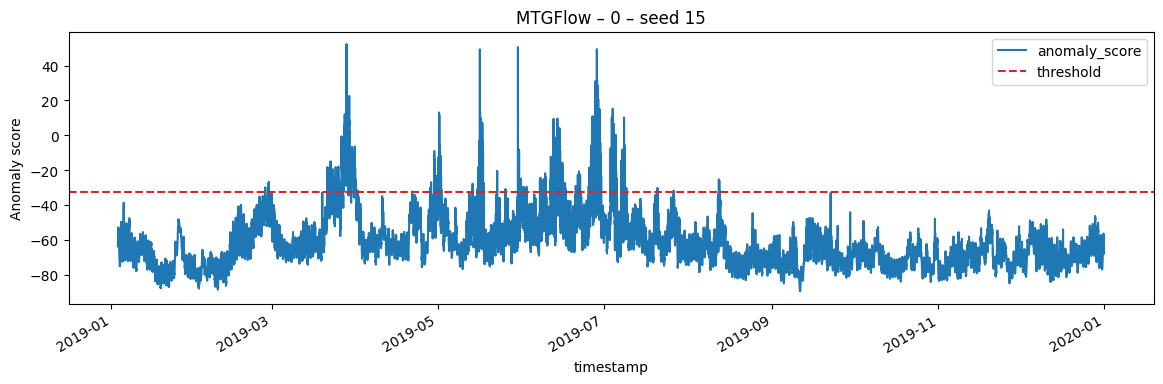

{'method': 'mtgflow',
 'alignment_policy': 'paper_when_explicit_official_repo_when_underspecified',
 'seeds': [15],
 'reference_seed_suite_matched': False,
 'epochs': 40,
 'window_size': 60,
 'batch_size': 256,
 'n_blocks': 2,
 'train_stride': 10,
 'score_stride': 1,
 'export_train_years': [2016, 2017, 2018],
 'iqr_k': 1.5,
 'entity_threshold_scale': 0.8,
 'scoring_profile': 'dense_hourly_window_adaptation',
 'reference_protocol_matched': False,
 'reference_protocol_deviations': ['score_stride=1 (reference 10)',
  'seeds=[15] (reference suite [15, 16, 17, 18, 19])'],
 'original_benchmark_reproduction': False,
 'original_benchmark_reproduction_note': 'PVGIS climate entities and chronological years replace the paper benchmark datasets.',
 'window_score_semantics': 'whole_window_assigned_to_window_end',
 'preparation_metadata_verified': True,
 'scores_aggregated_across_seeds': False,
 'environment': {'python': '3.12.3',
  'platform': 'Linux-6.8.0-124-generic-x86_64-with-glibc2.39',
  'num

In [8]:
ANALYSIS_ROOT = DOWNSTREAM_OUTPUT
SEED = DOWNSTREAM_SEED
scores_path = ANALYSIS_ROOT / f'seed_{SEED}' / 'anomaly_scores.csv'
train_scores_path = ANALYSIS_ROOT / f'seed_{SEED}' / 'train_anomaly_scores.csv'
metadata_path = ANALYSIS_ROOT / 'run_metadata.json'

if scores_path.is_file():
    scores = pd.read_csv(scores_path, parse_dates=['timestamp'])
    print(f'Score test caricati: {len(scores):,}')
    if train_scores_path.is_file():
        train_scores = pd.read_csv(train_scores_path, parse_dates=['timestamp'])
        print(f'Score training caricati: {len(train_scores):,}')
    display(scores.head())
    summary = scores.groupby('location').agg(
        n_windows=('is_anomaly', 'size'),
        n_anomaly=('is_anomaly', 'sum'),
        mean_score=('anomaly_score', 'mean'),
    )
    summary['anomaly_rate'] = summary['n_anomaly'] / summary['n_windows']
    display(summary.sort_values('anomaly_rate', ascending=False).head(20))

    first_location = scores['location'].iloc[0]
    selected = scores[scores['location'] == first_location]
    ax = selected.plot(x='timestamp', y='anomaly_score', figsize=(14, 4), legend=False)
    ax.axhline(selected['threshold'].iloc[0], color='tab:red', linestyle='--', label='threshold')
    ax.set_title(f'MTGFlow – {first_location} – seed {SEED}')
    ax.set_ylabel('Anomaly score')
    ax.legend()
    plt.show()
else:
    print('CSV non trovato:', scores_path)

if metadata_path.is_file():
    run_metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
    display(run_metadata)